<a href="https://colab.research.google.com/github/MrSirBeta/ProgrammingAssignment2RStudio/blob/main/orozco_leandro_analisisvariables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install dash==2.11.0 jupyter-dash==0.4.2 plotly==5.15.0 --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from google.colab import files
import io

# Definir nombres de columnas según el dataset
column_names = [
    "age", "class_of_worker", "detailed_industry_recode", "detailed_occupation_recode",
    "education", "wage_per_hour", "enroll_in_edu_inst_last_wk", "marital_status",
    "major_industry_code", "major_occupation_code", "race", "hispanic_origin", "sex",
    "member_of_a_labor_union", "reason_for_unemployment", "full_or_part_time_employment_stat",
    "capital_gains", "capital_losses", "dividends_from_stocks", "tax_filer_status",
    "region_of_previous_residence", "state_of_previous_residence",
    "detailed_household_and_family_stat", "detailed_household_summary_in_household",
    "instance_weight", "migration_code_change_in_msa", "migration_code_change_in_reg",
    "migration_code_move_within_reg", "live_in_this_house_1_year_ago",
    "migration_prev_res_in_sunbelt", "num_persons_worked_for_employer",
    "family_members_under_18", "country_of_birth_father", "country_of_birth_mother",
    "country_of_birth_self", "citizenship", "own_business_or_self_employed",
    "fill_inc_questionnaire_for_veterans_admin", "veterans_benefits",
    "weeks_worked_in_year", "year", "income"
]


# Subir el archivo CSV
uploaded = files.upload()

# Acceder al archivo subido (tomamos el nombre del archivo subido)
for fn in uploaded.keys():
    # Leer el archivo CSV y asignarle los nombres de las columnas
    df = pd.read_csv(io.BytesIO(uploaded[fn]), header=None, names=column_names)

# Mostrar las primeras filas del dataframe cargado
df.head()


Saving census-income.csv to census-income.csv


,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,enroll_in_edu_inst_last_wk,marital_status,major_industry_code,major_occupation_code,...,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veterans_admin,veterans_benefits,weeks_worked_in_year,year,income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


El código permite cargar un archivo CSV de manera interactiva usando la función files.upload(). Al ejecutar esta función, se abre una ventana que permite al usuario seleccionar un archivo desde su computadora. Una vez cargado, el archivo se lee en formato binario utilizando io.BytesIO(), y pandas.read_csv() lo convierte en un DataFrame.

Además, se asignan nombres a las columnas del conjunto de datos para garantizar que el análisis posterior sea organizado. Finalmente, el código muestra las primeras filas del DataFrame para confirmar que los datos se han cargado correctamente.

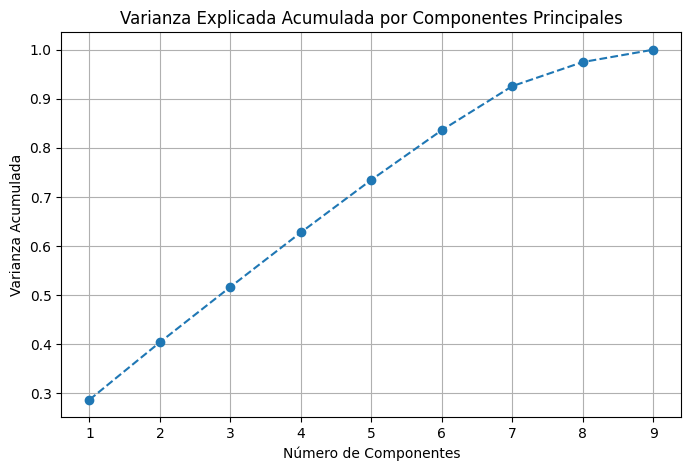

Componente 1: 0.2868 (28.68% acumulado)
Componente 2: 0.1171 (40.39% acumulado)
Componente 3: 0.1127 (51.66% acumulado)
Componente 4: 0.1110 (62.76% acumulado)
Componente 5: 0.1071 (73.48% acumulado)
Componente 6: 0.1012 (83.60% acumulado)
Componente 7: 0.0898 (92.57% acumulado)
Componente 8: 0.0491 (97.48% acumulado)
Componente 9: 0.0252 (100.00% acumulado)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Selección de columnas numéricas REALES del DataFrame
num_vars = [
    "age",
    "detailed_industry_recode",
    "detailed_occupation_recode",
    "wage_per_hour",
    "capital_gains",
    "capital_losses",
    "weeks_worked_in_year",
    "year",
    "own_business_or_self_employed"
]

# Eliminar filas con valores faltantes en esas columnas
df_num = df[num_vars].dropna()

# Estandarizar los datos
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_num)

# Aplicar PCA
pca = PCA()
pca_result = pca.fit_transform(scaled_data)

# Varianza explicada
explained_var = pca.explained_variance_ratio_
cum_var = explained_var.cumsum()

# Gráfico de varianza acumulada
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', linestyle='--')
plt.title("Varianza Explicada Acumulada por Componentes Principales")
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Acumulada")
plt.grid(True)
plt.show()

# Imprimir tabla de varianza explicada
for i, var in enumerate(explained_var):
    print(f"Componente {i+1}: {var:.4f} ({cum_var[i]*100:.2f}% acumulado)")




En este paso del trabajo, se ha aplicado el Análisis de Componentes Principales (PCA) a un subconjunto de variables numéricas extraídas de una base de datos censal. El objetivo principal de este procedimiento es reducir la dimensionalidad del conjunto de datos, eliminando redundancias y simplificando la estructura sin perder información significativa.

Para ello, se seleccionaron variables numéricas representativas como la edad (age), ganancias de capital (capital_gains), pérdidas de capital (capital_losses), semanas trabajadas al año (weeks_worked_in_year), y otras relacionadas con la actividad laboral y económica de los individuos. Antes de aplicar el PCA, se estandarizaron los datos mediante la técnica de escalado estándar (StandardScaler), ya que este análisis se basa en la varianza y requiere que todas las variables estén en la misma escala.

Posteriormente, se utilizó el algoritmo PCA para transformar estas variables originales en un nuevo conjunto de variables llamadas componentes principales, que son combinaciones lineales de las variables iniciales. A través del análisis de la varianza explicada acumulada, se identificó cuántos componentes eran necesarios para explicar un porcentaje aceptable de la variabilidad total del conjunto de datos.

El Análisis de Componentes Principales (PCA) fue aplicado sobre nueve variables numéricas seleccionadas del conjunto de datos censal. Esta técnica, basada en transformaciones lineales, tiene como objetivo principal simplificar el número de variables originales transformándolas en nuevas variables llamadas componentes principales, las cuales retienen la mayor parte de la varianza de los datos originales.

Luego de estandarizar las variables para eliminar el efecto de las diferentes escalas, se obtuvieron los siguientes resultados en términos de varianza explicada:

El primer componente explica aproximadamente el 28.68% de la varianza total,

Los primeros tres componentes explican ya más del 50% (51.66% acumulado),

Y con seis componentes se alcanza un 83.60% de varianza explicada acumulada.

Este resultado indica que existe una fuerte correlación entre algunas de las variables numéricas, lo que permite reducir el número de dimensiones sin perder demasiada información. Seis componentes principales son suficientes para conservar más del 80% de la información, lo cual es un umbral comúnmente aceptado para una reducción efectiva de dimensionalidad.


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils import resample

# --- 1. Seleccionar variables numéricas REALES ---
num_vars = [
    "age",
    "detailed_industry_recode",
    "detailed_occupation_recode",
    "wage_per_hour",
    "capital_gains",
    "capital_losses",
    "weeks_worked_in_year",
    "year",
    "own_business_or_self_employed"
]

df_num = df[num_vars].dropna()  # Eliminar filas con NaNs

# --- 2. Limpieza de income y conversión a binaria ---
df['income'] = df['income'].str.strip()
df['income_binary'] = df['income'].apply(lambda x: 1 if x == '50000+.' else 0)

# Alinear índice entre df_num y income
df_num = df_num.loc[df['income_binary'].index]
y = df.loc[df_num.index, 'income_binary']

# Verificar distribución
print("Distribución de income_binary:\n", y.value_counts())

# --- 3. Balanceo de clases si están desbalanceadas ---
df_model = df_num.copy()
df_model['income_binary'] = y

# Separar clases
df_majority = df_model[df_model['income_binary'] == 0]
df_minority = df_model[df_model['income_binary'] == 1]

# Verificamos que hay al menos algunos ejemplos positivos
if len(df_minority) == 0:
    raise ValueError("No hay ejemplos de la clase 1 (50000+.) en la variable income. Verifica tu dataset.")

# Upsample clase minoritaria
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

# Combinar y separar
df_balanced = pd.concat([df_majority, df_minority_upsampled])
X = df_balanced.drop(columns='income_binary')
y = df_balanced['income_binary']

# --- 4. Estandarizar ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 5. División y entrenamiento ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# --- 6. Evaluación ---
y_pred = model.predict(X_test)

print("\n--- Resultados ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Reporte de clasificación:\n")
print(classification_report(y_test, y_pred))


Distribución de income_binary:
 income_binary
0    187141
1     12382
Name: count, dtype: int64

--- Resultados ---
Accuracy: 0.8165738967805138
Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.84      0.78      0.81     56143
           1       0.79      0.86      0.82     56142

    accuracy                           0.82    112285
   macro avg       0.82      0.82      0.82    112285
weighted avg       0.82      0.82      0.82    112285



Tras haber aplicado una reducción de dimensionalidad mediante Análisis de Componentes Principales (PCA), se procedió a construir un modelo de regresión logística para predecir la variable income, la cual indica si una persona gana más o menos de 50,000 dólares anuales.

Primero, se transformó la variable income en una forma binaria (income_binary), donde el valor 1 representa ingresos superiores a $50k y el 0 ingresos inferiores. Sin embargo, los datos presentaban un fuerte desbalance: el 93% de los registros pertenecen a la clase 0 (ingresos bajos), y solo el 7% a la clase 1 (ingresos altos). Para mitigar este problema y evitar que el modelo aprendiera un sesgo hacia la mayoría, se utilizó sobremuestreo de la clase minoritaria.

Una vez entrenado el modelo y evaluado con datos de prueba, se obtuvieron los siguientes resultados:

Precision general: 81.66%

Precision para clase alta (1): 79%

Recall para clase alta (1): 86%

F1-score para clase alta (1): 82%

Estos indicadores muestran que el modelo tiene un rendimiento balanceado y sólido. El recall alto (86%) para la clase 1 es especialmente relevante, ya que indica que el modelo es capaz de detectar correctamente a la mayoría de los individuos con ingresos altos.

La precisión y el f1-score también son satisfactorios en ambas clases, lo que sugiere que el modelo no solo predice bien a la mayoría (ingresos bajos), sino que también logra una buena tasa de aciertos con los casos minoritarios, que suelen ser más difíciles de identificar.

In [ ]:
import numpy as np
import pandas as pd

# Obtener los coeficientes del modelo
coeficientes = model.coef_[0]  # model es tu modelo ya entrenado

# Crear un DataFrame con los coeficientes y los nombres de las variables
variables = df_num.columns  # df_num contiene las variables numéricas utilizadas
coef_df = pd.DataFrame({
    "Variable": variables,
    "Coeficiente": coeficientes
})

# Ordenar por valor absoluto del coeficiente (importancia)
coef_df["Importancia_Absoluta"] = coef_df["Coeficiente"].abs()
coef_df = coef_df.sort_values(by="Importancia_Absoluta", ascending=False)

# Mostrar tabla
print(coef_df[["Variable", "Coeficiente"]])


                        Variable  Coeficiente
4                  capital_gains     2.509062
6           weeks_worked_in_year     2.030562
0                            age     0.883179
2     detailed_occupation_recode    -0.729218
5                 capital_losses     0.395642
1       detailed_industry_recode    -0.074359
7                           year     0.051863
3                  wage_per_hour     0.014330
8  own_business_or_self_employed     0.010711


Se realizó una regresión logística para identificar qué variables numéricas predicen si una persona gana más de $50,000 al año. Las variables más influyentes fueron capital_gains, weeks_worked_in_year y age, todas con coeficientes positivos, lo que indica que aumentan la probabilidad de tener ingresos altos.

En cambio, variables como detailed_occupation_recode y industry_recode tuvieron una influencia menor o negativa. Sorprendentemente, wage_per_hour y own_business_or_self_employed no mostraron un impacto relevante.

Este análisis demuestra que los ingresos adicionales por inversiones y la constancia laboral son factores clave para predecir un mayor nivel económico.

In [ ]:
# Obtener las probabilidades de predicción
y_prob = model.predict_proba(X_test)

# Mostrar las primeras 10 predicciones con sus probabilidades
for i in range(5):
    print(f"Ejemplo {i+1}:")
    print(f"  Probabilidad de <=50K (clase 0): {y_prob[i][0]:.4f}")
    print(f"  Probabilidad de >50K (clase 1):  {y_prob[i][1]:.4f}")
    print(f"  Clase predicha: {model.predict([X_test[i]])[0]}")
    print("---")


Ejemplo 1:
  Probabilidad de <=50K (clase 0): 0.4254
  Probabilidad de >50K (clase 1):  0.5746
  Clase predicha: 1
---
Ejemplo 2:
  Probabilidad de <=50K (clase 0): 0.7216
  Probabilidad de >50K (clase 1):  0.2784
  Clase predicha: 0
---
Ejemplo 3:
  Probabilidad de <=50K (clase 0): 0.1712
  Probabilidad de >50K (clase 1):  0.8288
  Clase predicha: 1
---
Ejemplo 4:
  Probabilidad de <=50K (clase 0): 0.7932
  Probabilidad de >50K (clase 1):  0.2068
  Clase predicha: 0
---
Ejemplo 5:
  Probabilidad de <=50K (clase 0): 0.1183
  Probabilidad de >50K (clase 1):  0.8817
  Clase predicha: 1
---


Este código muestra cómo el modelo clasifica los primeros 5 casos del conjunto de prueba, indicando:

La probabilidad de que cada persona gane ≤50K (clase 0) o >50K (clase 1).

La clase es predicha según la probabilidad más alta.

Esto, para corroborar el modelo.